In [1]:
import pandas as pd
from pathlib import Path

DATASET_PATH = Path("../data/nfl-big-data-bowl-2026-prediction/train")

INPUT_PATH = DATASET_PATH / "input_2023_w01.csv"
OUTPUT_PATH = DATASET_PATH / "output_2023_w01.csv"

df_input = pd.read_csv(INPUT_PATH)
df_output = pd.read_csv(OUTPUT_PATH)

print("Input shape:", df_input.shape)
print("Output shape:", df_output.shape)

Input shape: (285714, 23)
Output shape: (32088, 6)


In [2]:
print("COLUMNAS INPUT:")
print(df_input.columns.tolist())

print("\nCOLUMNAS OUTPUT:")
print(df_output.columns.tolist())

COLUMNAS INPUT:
['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y']

COLUMNAS OUTPUT:
['game_id', 'play_id', 'nfl_id', 'frame_id', 'x', 'y']


In [3]:
df_input.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


In [4]:
df_output.head()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023090700,101,46137,1,56.22,17.28
1,2023090700,101,46137,2,56.63,16.88
2,2023090700,101,46137,3,57.06,16.46
3,2023090700,101,46137,4,57.48,16.02
4,2023090700,101,46137,5,57.91,15.56


In [5]:
# Ver algunos partidos y jugadas disponibles
df_input[["game_id", "play_id"]].drop_duplicates().head(10)

,game_id,play_id
0,2023090700,101
234,2023090700,194
650,2023090700,219
871,2023090700,361
1432,2023090700,436
1652,2023090700,461
1951,2023090700,530
2211,2023090700,621
2588,2023090700,713
2900,2023090700,736


In [6]:
# Tomamos la primera jugada del dataset
sample_play = df_input[["game_id", "play_id"]].drop_duplicates().iloc[0]

sample_game_id = sample_play["game_id"]
sample_play_id = sample_play["play_id"]

sample_game_id, sample_play_id

(np.int64(2023090700), np.int64(101))

In [7]:
play_input = df_input[
    (df_input["game_id"] == sample_game_id) &
    (df_input["play_id"] == sample_play_id)
]

play_output = df_output[
    (df_output["game_id"] == sample_game_id) &
    (df_output["play_id"] == sample_play_id)
]

print("Input jugada:", play_input.shape)
print("Output jugada:", play_output.shape)

Input jugada: (234, 23)
Output jugada: (63, 6)


In [8]:
play_input.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


In [9]:
print("Input jugada:", play_input.shape)
print("Output jugada:", play_output.shape)

Input jugada: (234, 23)
Output jugada: (63, 6)


In [10]:
play_input.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


In [11]:
play_output.head()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023090700,101,46137,1,56.22,17.28
1,2023090700,101,46137,2,56.63,16.88
2,2023090700,101,46137,3,57.06,16.46
3,2023090700,101,46137,4,57.48,16.02
4,2023090700,101,46137,5,57.91,15.56


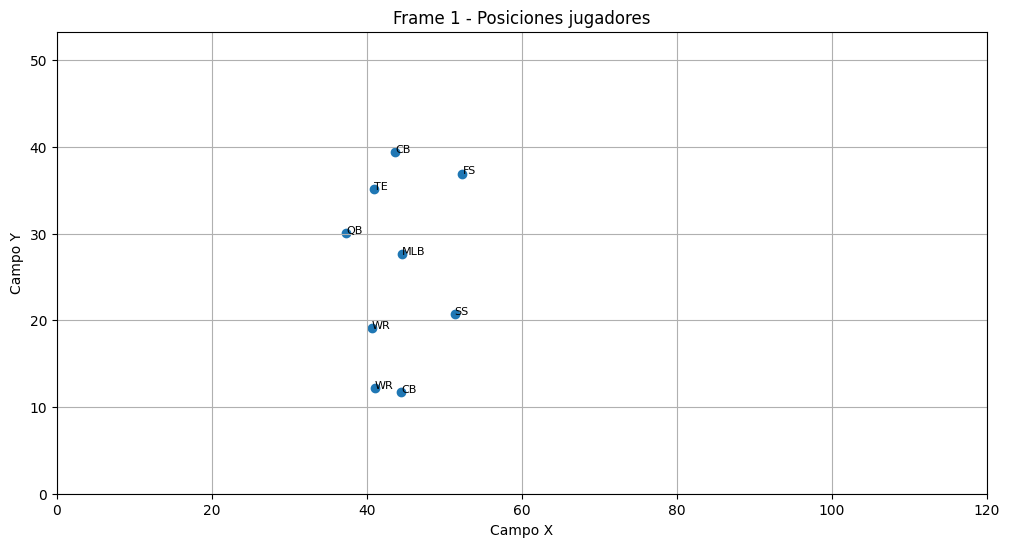

In [12]:
import matplotlib.pyplot as plt

# Tomar un frame específico
frame_example = play_input[play_input["frame_id"] == 1]

plt.figure(figsize=(12, 6))

# Dibujar jugadores
plt.scatter(frame_example["x"], frame_example["y"])

# Mostrar nombres
for _, row in frame_example.iterrows():
    plt.text(row["x"], row["y"], row["player_position"], fontsize=8)

plt.xlim(0, 120)
plt.ylim(0, 53.3)

plt.title("Frame 1 - Posiciones jugadores")
plt.xlabel("Campo X")
plt.ylabel("Campo Y")

plt.grid(True)

plt.show()

In [13]:
sample_game_id

np.int64(2023090700)

In [14]:
sample_play_id

np.int64(101)

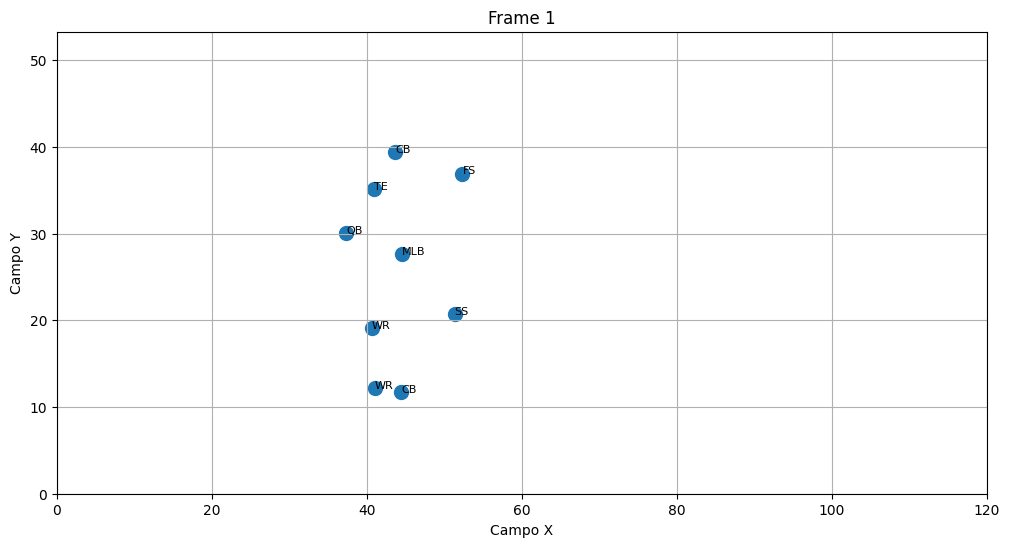

In [15]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Obtener frames únicos
frames = sorted(play_input["frame_id"].unique())

fig, ax = plt.subplots(figsize=(12, 6))

def update(frame):

    ax.clear()

    current_frame = play_input[
        play_input["frame_id"] == frame
    ]

    ax.scatter(
        current_frame["x"],
        current_frame["y"],
        s=100
    )

    for _, row in current_frame.iterrows():
        ax.text(
            row["x"],
            row["y"],
            row["player_position"],
            fontsize=8
        )

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)

    ax.set_title(f"Frame {frame}")
    ax.set_xlabel("Campo X")
    ax.set_ylabel("Campo Y")

    ax.grid(True)

ani = FuncAnimation(
    fig,
    update,
    frames=frames[:30],
    interval=200
)

HTML(ani.to_jshtml())

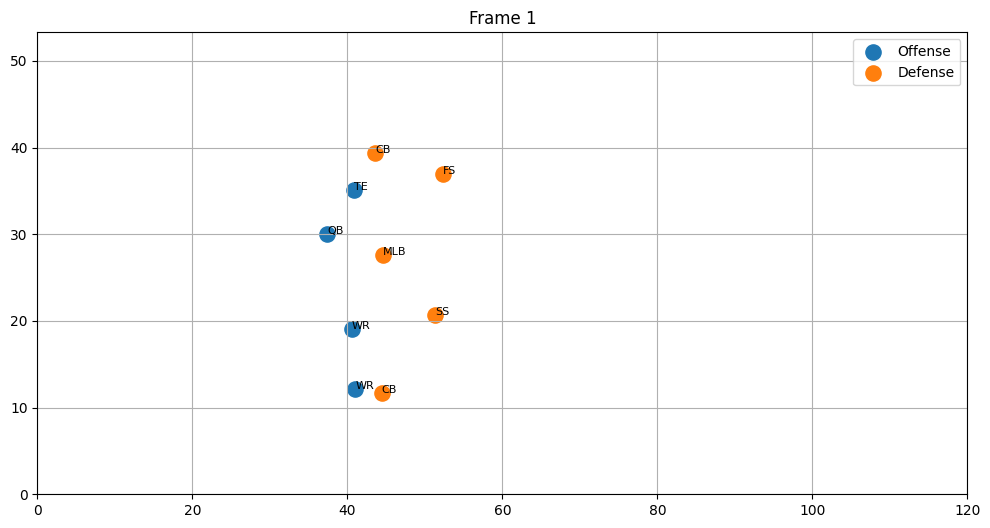

In [18]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

frames = sorted(play_input["frame_id"].unique())

fig, ax = plt.subplots(figsize=(12, 6))

def update(frame):

    ax.clear()

    current_frame = play_input[
        play_input["frame_id"] == frame
    ]

    offense = current_frame[
        current_frame["player_side"] == "Offense"
    ]

    defense = current_frame[
        current_frame["player_side"] == "Defense"
    ]

    ax.scatter(
        offense["x"],
        offense["y"],
        s=120,
        label="Offense"
    )

    ax.scatter(
        defense["x"],
        defense["y"],
        s=120,
        label="Defense"
    )

    for _, row in current_frame.iterrows():

        ax.text(
            row["x"],
            row["y"],
            row["player_position"],
            fontsize=8
        )

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)

    ax.set_title(f"Frame {frame}")

    ax.legend()

    ax.grid(True)

ani = FuncAnimation(
    fig,
    update,
    frames=frames[:40],
    interval=200
)

HTML(ani.to_jshtml())

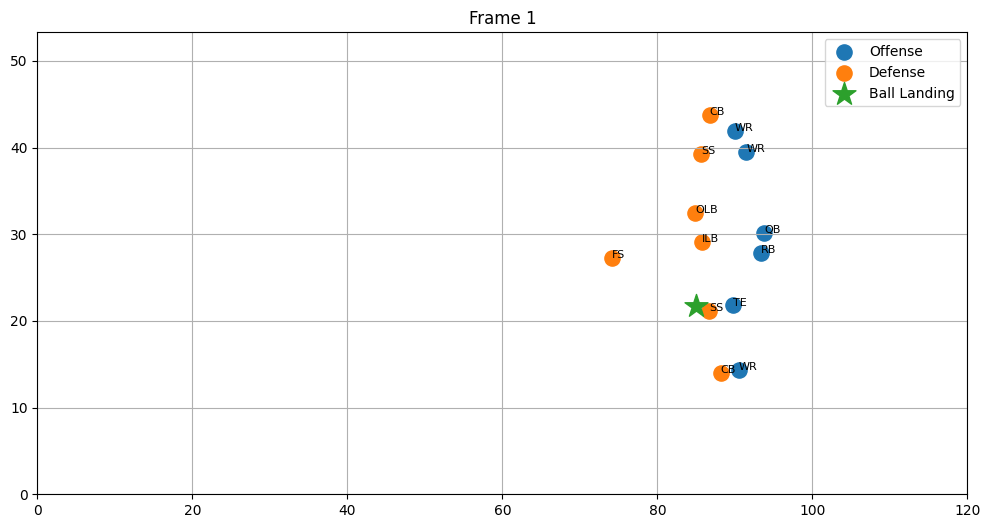

In [26]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

frames = sorted(play_input["frame_id"].unique())

fig, ax = plt.subplots(figsize=(12, 6))

def update(frame):
    
    ax.clear()
    
    current_frame = play_input[
        play_input["frame_id"] == frame
    ]
    
    offense = current_frame[
        current_frame["player_side"] == "Offense"
    ]
    
    defense = current_frame[
        current_frame["player_side"] == "Defense"
    ]
    
    # Ofensiva
    ax.scatter(
        offense["x"],
        offense["y"],
        s=120,
        label="Offense"
    )
    
    # Defensa
    ax.scatter(
        defense["x"],
        defense["y"],
        s=120,
        label="Defense"
    )
    
    # Texto posiciones
    for _, row in current_frame.iterrows():
        ax.text(
            row["x"],
            row["y"],
            row["player_position"],
            fontsize=8
        )
    
    # Balón
    ball_x = current_frame["ball_land_x"].iloc[0]
    ball_y = current_frame["ball_land_y"].iloc[0]
    
    # Validar coordenadas razonables
    if 0 <= ball_x <= 120 and 0 <= ball_y <= 53.3:
        ax.scatter(
            ball_x,
            ball_y,
            s=300,
            marker="*",
            label="Ball Landing"
        )
    
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    
    ax.set_title(f"Frame {frame}")
    ax.legend()
    ax.grid(True)

ani = FuncAnimation(
    fig,
    update,
    frames=frames[:40],
    interval=200
)

HTML(ani.to_jshtml())

In [24]:
valid_ball_plays = df_input[
    (df_input["ball_land_x"] >= 0) &
    (df_input["ball_land_x"] <= 120) &
    (df_input["ball_land_y"] >= 0) &
    (df_input["ball_land_y"] <= 53.3)
][["game_id", "play_id"]].drop_duplicates()

valid_ball_plays.head(10)

,game_id,play_id
234,2023090700,194
650,2023090700,219
871,2023090700,361
1432,2023090700,436
1652,2023090700,461
1951,2023090700,530
2211,2023090700,621
2588,2023090700,713
2900,2023090700,736
3272,2023090700,877


In [25]:
sample_play = valid_ball_plays.iloc[0]

sample_game_id = sample_play["game_id"]
sample_play_id = sample_play["play_id"]

play_input = df_input[
    (df_input["game_id"] == sample_game_id) &
    (df_input["play_id"] == sample_play_id)
]

play_output = df_output[
    (df_output["game_id"] == sample_game_id) &
    (df_output["play_id"] == sample_play_id)
]

print(sample_game_id, sample_play_id)
print("Input jugada:", play_input.shape)
print("Output jugada:", play_output.shape)
print("Ball land:", play_input["ball_land_x"].iloc[0], play_input["ball_land_y"].iloc[0])

2023090700 194
Input jugada: (416, 23)
Output jugada: (45, 6)
Ball land: 84.9400024414062 21.75


In [27]:
targets = play_input[
    play_input["player_to_predict"] == True
][[
    "nfl_id",
    "player_name",
    "player_position",
    "player_role"
]].drop_duplicates()

targets

,nfl_id,player_name,player_position,player_role
234,44888,Alex Anzalone,OLB,Defensive Coverage
266,55910,Brian Branch,SS,Defensive Coverage
362,53953,Jerry Jacobs,CB,Defensive Coverage
426,54653,Malcolm Rodriguez,ILB,Defensive Coverage
618,41325,Jerick McKinnon,RB,Targeted Receiver
